In [1]:
import numpy as np
import lib_debug

%load_ext autoreload
%autoreload 2

--- Strategy Selected: LCB ---
--- Starting Optimization Loop (15 iterations) ---
Iter  | Best y     | New y      | New x (approx)
--------------------------------------------------
1     | -0.941822   | -0.941822   | [0.57]
2     | -0.951209   | -0.951209   | [0.56]
3     | -0.951209   | -0.931395   | [0.56]
4     | -0.984724   | -0.984724   | [0.56]
5     | -0.984724   | -0.907635   | [0.57]
6     | -0.984724   | -0.914051   | [0.55]
7     | -0.984724   | -0.956149   | [0.55]
8     | -0.984724   | -0.895291   | [0.57]
9     | -0.984724   | -0.966839   | [0.55]
10    | -1.019481   | -1.019481   | [0.55]
11    | -1.019481   | -0.972369   | [0.55]
12    | -1.019481   | -0.965488   | [0.55]
13    | -1.019481   | -0.979835   | [0.55]
14    | -1.019481   | -0.929092   | [0.55]
15    | -1.019481   | -1.008556   | [0.55]


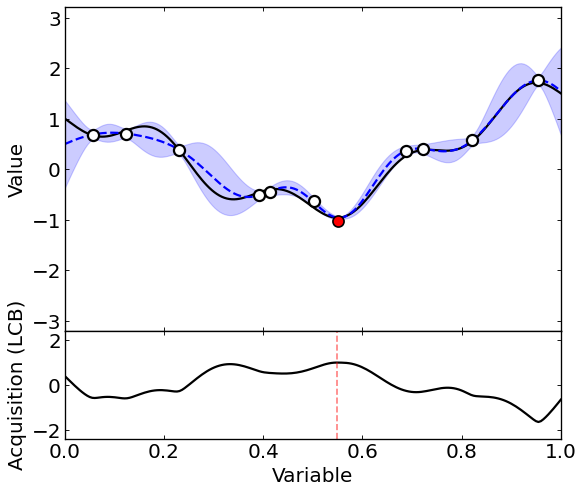

--------------------------------------------------
Optimization Finished using LCB.
Global Best Found: y = -1.019481


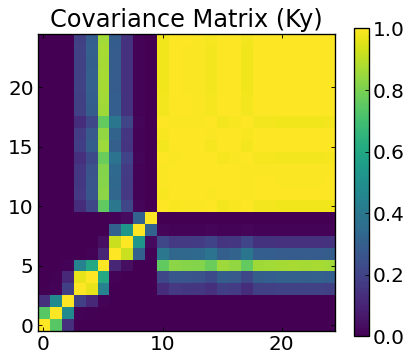

In [2]:
# -------------------- 1. Setup & Aliasing --------------------
kernel = lib_debug.rbf_kernel

# -------------------- 2. Settings --------------------
# Hyperparameters
gamma = 65.0
noise_std = 0.05
noise_var = noise_std ** 2

# Domain settings
dims = 1
lower_bounds = [0.0]
upper_bounds = [1.0]

# Optimization Loop Settings
n_init = 10
n_iter = 15
xi = 0.01

# Grid for plotting ONLY (No longer used for search loop)
X_grid = np.linspace(0, 1, 200)[:, None]

# --- Acquisition Function Selection ---
STRATEGY = "LCB"  # Options: "EI" or "LCB"

if STRATEGY == "EI":
    acq_func = lib_debug.expected_improvement
    acq_params = {'xi': 0.01}
elif STRATEGY == "LCB":
    acq_func = lib_debug.lower_confidence_bound
    acq_params = {'kappa': 2.0}
else:
    raise ValueError("Unknown strategy")

print(f"--- Strategy Selected: {STRATEGY} ---")

# -------------------- 3. Initialization --------------------
# Generate samples and observations
X_train = lib_debug.LHSsampler(dims, n_init, lower_bounds, upper_bounds)
X_train = X_train[np.argsort(X_train[:, 0])]
y_train = lib_debug.test_1D(X_train).reshape(-1, 1) + np.random.normal(0, noise_std, (len(X_train), 1))

# Keep copy for plotting
X_init_plot = X_train.copy()
y_init_plot = y_train.copy()

# -------------------- 4. Bayesian Optimization Loop --------------------
print(f"--- Starting Optimization Loop ({n_iter} iterations) ---")
print(f"{'Iter':<5} | {'Best y':<10} | {'New y':<10} | {'New x (approx)'}")
print("-" * 50)

for i in range(n_iter):
    
    # 1. Fit GP (Calculate Ky_inv)
    Ky_inv = lib_debug.fit_gp(kernel, X_train, gamma, noise_var)

    # 2. Find Next Point (Continuous Optimization instead of Grid Search)
    x_new, _ = lib_debug.optimize_acquisition(
        kernel, 
        acq_func, 
        X_train, y_train, Ky_inv, gamma, 
        lower_bounds, upper_bounds, acq_params
    )
    
    # 3. Evaluate True Function
    # x_new comes out as (dims,), need reshape for evaluation
    y_new = lib_debug.test_1D(x_new.reshape(1, -1)) + np.random.normal(0, noise_std, (1, 1))

    # 4. Update Data
    X_train = np.vstack([X_train, x_new])
    y_train = np.vstack([y_train, y_new])
    
    # Log
    current_best = np.min(y_train)
    print(f"{i+1:<5} | {current_best:.6f}   | {y_new.item():.6f}   | [{x_new[0]:.2f}]")


# -------------------- 5. Final Calculation & Visualization --------------------
# Re-fit GP with all data
Ky_inv = lib_debug.fit_gp(kernel, X_train, gamma, noise_var)

# Get predictions and acquisition values for plotting
# (Here we still use X_grid to draw the curves)
mu_list = []
sigma_list = []
acq_final_list = []

for x in X_grid:
    m, s = lib_debug.get_posterior(kernel, x, X_train, y_train, Ky_inv, gamma)
    mu_list.append(m)
    sigma_list.append(s)
    acq_final_list.append(acq_func(kernel, x, X_train, y_train, Ky_inv, gamma, **acq_params))

mu_post = np.array(mu_list)
s_post = np.array(sigma_list)
acq_final = np.array(acq_final_list)

# Identify Best Point
best_idx_final = np.argmin(y_train)
best_x = X_train[best_idx_final]
best_y = y_train[best_idx_final]

# Visualization
lib_debug.plot_gp_results(
    X_grid=X_grid,
    true_func=lib_debug.test_1D,
    X_init=X_init_plot,
    y_init=y_init_plot,
    best_x=best_x,
    best_y=best_y,
    mu=mu_post,
    sigma=s_post,
    acq_values=acq_final,
    strategy_name=STRATEGY
)

print("-" * 50)
print(f"Optimization Finished using {STRATEGY}.")
print(f"Global Best Found: y = {y_train[best_idx_final].item():.6f}")

# Final Covariance Plot
K_final = kernel(X_train, X_train, gamma)
lib_debug.plot_covariance_matrix(K_final)

[None, None, None, None, None, None, None, None, None, None]

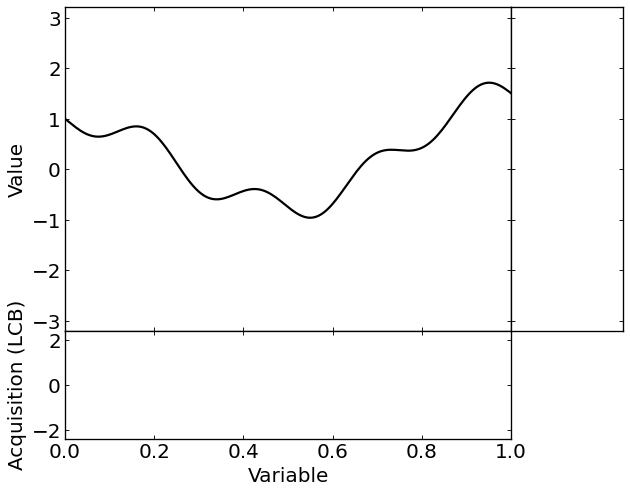

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import lib_debug

# 1D グリッド
X_grid = np.linspace(0.0, 1.0, 200)[:, None]

# 真の関数値
y_true = lib_debug.test_1D(X_grid)

fig = plt.figure(figsize=(9, 7), dpi=80)

gs = gridspec.GridSpec(
    2,
    2,
    height_ratios=[3, 1],
    width_ratios=[4, 1],
)
gs.update(hspace=0.0, wspace=0.0)  # ← スキマを完全に 0
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[1, 0], sharex=ax1)
ax3 = fig.add_subplot(gs[0, 1], sharey=ax1)
ax4 = fig.add_subplot(gs[1, 1], sharex=ax3, sharey=ax2)

# ax1: GP
ax1.plot(X_grid, y_true, "k-", label="True Function", linewidth=2)
ax1.set_ylim(-3.2, 3.2)
ax1.set_xlim(0, 1)
ax1.set_ylabel("Value")

# ax2: acquisition
ax2.set_ylim(-2.4, 2.4)
ax2.set_xlim(0, 1)
ax2.set_xlabel("Variable")
ax2.set_ylabel(f"Acquisition (LCB)")

# ax3: Covariance Matrix

# ax4: 完全に非表示にしたいなら
ax4.axis("off")
plt.setp(ax1.get_xticklabels(), visible=False)
plt.setp(ax3.get_xticklabels(), visible=False)
plt.setp(ax3.get_yticklabels(), visible=False)
plt.setp(ax4.get_yticklabels(), visible=False)

--- Snapshot 2: Strategy = LCB ---


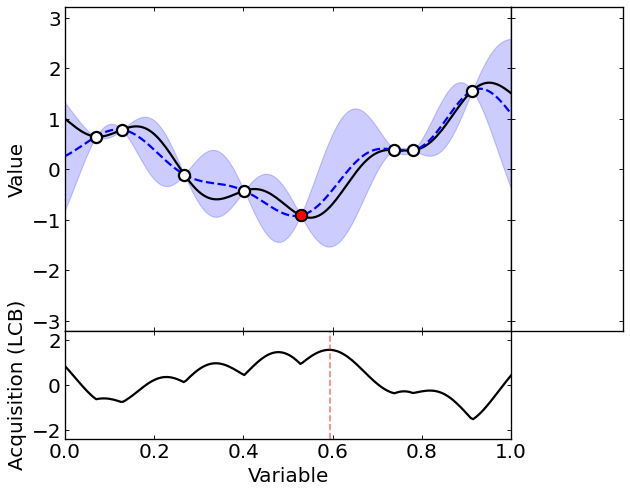

In [4]:
import numpy as np
import lib_debug

# -------------------- 1. Setup --------------------
kernel = lib_debug.rbf_kernel

# ハイパーパラメータ
gamma = 65.0
noise_std = 0.00
noise_var = noise_std ** 2

# 探索領域
dims = 1
lower_bounds = [0.0]
upper_bounds = [1.0]

# 初期サンプル数
n_init = 8

# グリッド（可視化専用）
X_grid = np.linspace(0.0, 1.0, 200)[:, None]

# 取得関数の選択
STRATEGY = "LCB"  # "EI" も可

if STRATEGY == "EI":
    acq_func = lib_debug.expected_improvement
    acq_params = {"xi": 0.01}
elif STRATEGY == "LCB":
    acq_func = lib_debug.lower_confidence_bound
    acq_params = {"kappa": 2.0}
else:
    raise ValueError("Unknown STRATEGY")

print(f"--- Snapshot 2: Strategy = {STRATEGY} ---")

# -------------------- 2. 初期サンプル生成 --------------------
X_train = lib_debug.LHSsampler(dims, n_init, lower_bounds, upper_bounds)
# 1 次元なので x 座標でソート
X_train = X_train[np.argsort(X_train[:, 0])]

# 真の関数 + ノイズ
y_train = lib_debug.test_1D(X_train).reshape(-1, 1)
y_train = y_train + np.random.normal(0.0, noise_std, size=(len(X_train), 1))

# プロット用にコピー（X_init, y_init として使う）
X_init = X_train.copy()
y_init = y_train.copy()

# -------------------- 3. GP フィット --------------------
Ky_inv = lib_debug.fit_gp(kernel, X_train, gamma, noise_var)

# -------------------- 4. グリッド上で事後分布 & 取得関数計算 --------------------
mu_list = []
sigma_list = []
acq_list = []

for x in X_grid:
    mu_x, sigma_x = lib_debug.get_posterior(kernel, x, X_train, y_train, Ky_inv, gamma)
    mu_list.append(mu_x)
    sigma_list.append(sigma_x)
    acq_val = acq_func(kernel, x, X_train, y_train, Ky_inv, gamma, **acq_params)
    acq_list.append(acq_val)

mu_post = np.array(mu_list)     # (200, 1) 想定
sigma_post = np.array(sigma_list)
acq_values = np.array(acq_list) # (200, 1) か (200,) 想定

# 観測値の中の最良点
best_idx = np.argmin(y_train)
best_x = X_train[best_idx]
best_y = y_train[best_idx]

fig, ax1, ax2, ax3, ac4 = lib_debug.plot_gp_results_enhanced(X_grid, 
                                   true_func=lib_debug.test_1D,
                                   X_init=X_init,
                                   y_init=y_init,
                                   best_x=best_x,
                                   best_y=best_y,
                                   mu_post=mu_post,
                                   sigma_post=sigma_post,
                                   acq_values=acq_values,
                                   strategy_name=STRATEGY,)


--- Snapshot 2: Strategy = LCB ---
Best y (from initial samples only): -0.915736 at x = 0.5283
Projection direction norm: 1.0
Prior proj:   mean = 0.0000, std = 1.0000
Posterior proj: mean = 0.1087, std = 0.5579


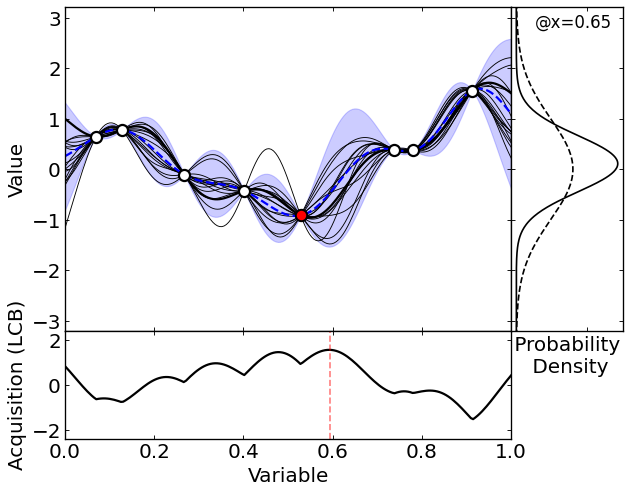

In [5]:
import numpy as np
import lib_debug

# -------------------- 1. Setup --------------------
kernel = lib_debug.rbf_kernel

# ハイパーパラメータ
gamma = 65.0
noise_std = 0.00
noise_var = noise_std**2

# 探索領域
dims = 1
lower_bounds = [0.0]
upper_bounds = [1.0]

# 初期サンプル数
n_init = 8

# グリッド（可視化専用）
X_grid = np.linspace(0.0, 1.0, 200)[:, None]

# 取得関数の選択
STRATEGY = "LCB"  # "EI" も可

if STRATEGY == "EI":
    acq_func = lib_debug.expected_improvement
    acq_params = {"xi": 0.01}
elif STRATEGY == "LCB":
    acq_func = lib_debug.lower_confidence_bound
    acq_params = {"kappa": 2.0}
else:
    raise ValueError("Unknown STRATEGY")

print(f"--- Snapshot 2: Strategy = {STRATEGY} ---")

# -------------------- 2. 初期サンプル生成 --------------------
X_train = lib_debug.LHSsampler(dims, n_init, lower_bounds, upper_bounds)
# 1 次元なので x 座標でソート
X_train = X_train[np.argsort(X_train[:, 0])]

# 真の関数 + ノイズ
y_train = lib_debug.test_1D(X_train).reshape(-1, 1)
y_train = y_train + np.random.normal(0.0, noise_std, size=(len(X_train), 1))

# プロット用にコピー（X_init, y_init として使う）
X_init = X_train.copy()
y_init = y_train.copy()

# -------------------- 3. GP フィット --------------------
Ky_inv = lib_debug.fit_gp(kernel, X_train, gamma, noise_var)

# -------------------- 4. グリッド上で事後分布 & 取得関数計算 --------------------
mu_list = []
sigma_list = []
acq_list = []

for x in X_grid:
    mu_x, sigma_x = lib_debug.get_posterior(kernel, x, X_train, y_train, Ky_inv, gamma)
    mu_list.append(mu_x)
    sigma_list.append(sigma_x)
    acq_val = acq_func(kernel, x, X_train, y_train, Ky_inv, gamma, **acq_params)
    acq_list.append(acq_val)

mu_post = np.array(mu_list)  # (200, 1) 想定
sigma_post = np.array(sigma_list)
acq_values = np.array(acq_list)  # (200, 1) か (200,) 想定

# 観測値の中の最良点
best_idx = np.argmin(y_train)
best_x = X_train[best_idx]
best_y = y_train[best_idx]

fig, ax1, ax2, ax3, ac4 = lib_debug.plot_gp_results_enhanced(X_grid, 
                                   true_func=lib_debug.test_1D,
                                   X_init=X_init,
                                   y_init=y_init,
                                   best_x=best_x,
                                   best_y=best_y,
                                   mu_post=mu_post,
                                   sigma_post=sigma_post,
                                   acq_values=acq_values,
                                   strategy_name=STRATEGY,)

print(f"Best y (from initial samples only): {best_y.item():.6f} at x = {best_x[0]:.4f}")

# -------------------- 6. posterior から関数サンプルを生成 --------------------
# X_grid 上での GP posterior の共分散行列を作る
# K_xx: cov(X_grid, X_grid)
K_xx = kernel(X_grid, X_grid, gamma)  # 形状: (n_grid, n_grid)

# K_xX: cov(X_grid, X_train)
K_xX = kernel(X_grid, X_train, gamma)  # 形状: (n_grid, n_train)

# posterior 共分散: K_xx - K_xX @ Ky_inv @ K_xX^T
Cov_post = K_xx - K_xX @ Ky_inv @ K_xX.T  # (n_grid, n_grid)

# 数値誤差で非対称になるのを防ぐ & 対角に微小な jitter を足す
Cov_post = 0.5 * (Cov_post + Cov_post.T)
Cov_post = Cov_post + 1e-8 * np.eye(Cov_post.shape[0])

# 平均ベクトル（1 次元に flatten）
mean_post = mu_post.ravel()  # 長さ n_grid の 1D ベクトル

# 多変量正規分布から関数サンプルを生成
num_samples = 15
samples = np.random.multivariate_normal(mean_post, Cov_post, size=num_samples)

# サンプルを GP プロットの上に重ね描き
x_plot = X_grid.ravel()
for i in range(num_samples):
    ax1.plot(
        x_plot,
        samples[i],
        color="k",
        lw=0.8,
        alpha=1.0,
        zorder=1
    )



# グリッドの次元
n_grid = X_grid.shape[0]

# ---- 1. prior の多変量ガウス (f(X_grid)) ----
# 平均は 0 ベクトル
mu_prior = np.zeros(n_grid)
# 共分散は K(X_grid, X_grid)
K_prior = kernel(X_grid, X_grid, gamma)  # shape: (n_grid, n_grid)

# ---- 2. posterior の多変量ガウス (f(X_grid) | データ) ----
# K_*X = cov(X_grid, X_train)
K_xX = kernel(X_grid, X_train, gamma)      # (n_grid, n_train)

# posterior 共分散: K_* - K_*X Ky_inv K_X*
Cov_post = K_prior - K_xX @ Ky_inv @ K_xX.T
# 対称化 + jitter
Cov_post = 0.5 * (Cov_post + Cov_post.T)
Cov_post = Cov_post + 1e-8 * np.eye(n_grid)

# posterior 平均ベクトル
mu_post_vec = mu_post.ravel()              # (n_grid,)

# ---- 3. 射影する方向ベクトル v を決める ----
# 例: 全要素 1 のベクトルを正規化（「全体平均」方向のようなもの）
v = np.ones(n_grid)
v = v / np.linalg.norm(v)
# 例えば x0 = 0.5 付近の点の方向を取りたい
x0 = 0.65
idx = np.argmin(np.abs(X_grid.ravel() - x0))  # 一番近いグリッド index

v = np.zeros(n_grid)
v[idx] = 1.0      # e_k ベクトル (その点だけを抜き出す方向)


# ---- 4. 射影後の 1 次元ガウスの平均・分散 ----
# prior: Z_prior = v^T f  ~ N(m0, s0^2)
mean_prior_proj = v @ mu_prior
var_prior_proj = v @ K_prior @ v

# posterior: Z_post = v^T f | data ~ N(m1, s1^2)
mean_post_proj = v @ mu_post_vec
var_post_proj = v @ Cov_post @ v

std_prior_proj = np.sqrt(var_prior_proj)
std_post_proj = np.sqrt(var_post_proj)

print("Projection direction norm:", np.linalg.norm(v))
print("Prior proj:   mean = {:.4f}, std = {:.4f}".format(mean_prior_proj, std_prior_proj))
print("Posterior proj: mean = {:.4f}, std = {:.4f}".format(mean_post_proj, std_post_proj))

# ---- 5. 1 次元ガウスの pdf をプロット ----
# x 軸（射影されたランダム変数の取りうる値の軸）
# prior/posterior が両方入るように、広めに取る
z_min = min(mean_prior_proj - 4 * std_prior_proj, mean_post_proj - 4 * std_post_proj)
z_max = max(mean_prior_proj + 4 * std_prior_proj, mean_post_proj + 4 * std_post_proj)
z = np.linspace(z_min, z_max, 400)

def normal_pdf(z, mean, var):
    return 1.0 / np.sqrt(2.0 * np.pi * var) * np.exp(-0.5 * (z - mean) ** 2 / var)

pdf_prior = normal_pdf(z, mean_prior_proj, var_prior_proj)
pdf_post = normal_pdf(z, mean_post_proj, var_post_proj)

ax3.plot(pdf_prior, z, label="Prior", c='k', linestyle="--")
ax3.plot(pdf_post, z, label="Posterior", c='k', linestyle="-")
ax3.text(0.13, 2.8, f"@x=0.65", fontsize=15)
ax3.set_xlabel(" Probability \n Density")


# save
_pdf_post = normal_pdf(z, mean_post_proj, var_post_proj)

--- Snapshot 3: Strategy = LCB ---
New sample from acquisition: x = 0.5922, y = -0.760711, acq = 1.554906
Best y (from initial samples only): -0.915736 at x = 0.5283
Projection direction norm: 1.0
Prior proj:   mean = 0.0000, std = 1.0000
Posterior proj: mean = -0.1550, std = 0.2072


Text(0.35, 2.8, '@x=0.65')

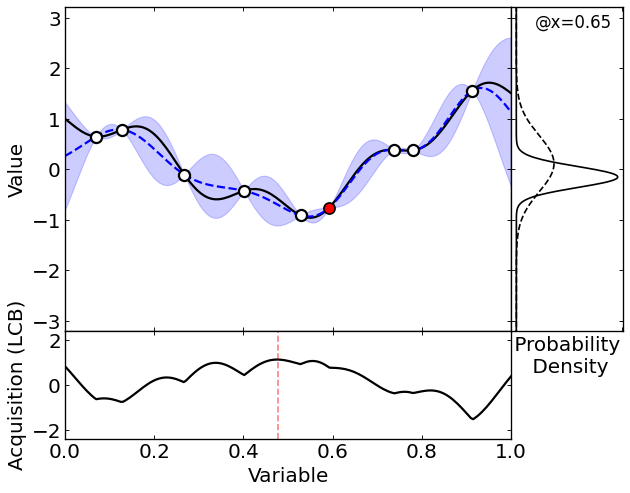

In [6]:
import numpy as np
import lib_debug

# -------------------- 1. Setup --------------------
kernel = lib_debug.rbf_kernel

# ハイパーパラメータ
gamma = 65.0
noise_std = 0.00
noise_var = noise_std ** 2

# 探索領域
dims = 1
lower_bounds = [0.0]
upper_bounds = [1.0]

# 初期サンプル数
n_init = 8

# グリッド（可視化専用）
X_grid = np.linspace(0.0, 1.0, 200)[:, None]

# 取得関数の選択
STRATEGY = "LCB"  # "EI" も可

if STRATEGY == "EI":
    acq_func = lib_debug.expected_improvement
    acq_params = {"xi": 0.01}
elif STRATEGY == "LCB":
    acq_func = lib_debug.lower_confidence_bound
    acq_params = {"kappa": 2.0}
else:
    raise ValueError("Unknown STRATEGY")

print(f"--- Snapshot 3: Strategy = {STRATEGY} ---")

# -------------------- 2. 初期サンプル生成 --------------------
X_train = lib_debug.LHSsampler(dims, n_init, lower_bounds, upper_bounds)
X_train = X_train[np.argsort(X_train[:, 0])]

y_train = lib_debug.test_1D(X_train).reshape(-1, 1)
y_train = y_train + np.random.normal(0.0, noise_std, size=(len(X_train), 1))

# 「初期サンプル」として別に保持（可視化のため）
X_init = X_train.copy()
y_init = y_train.copy()

# -------------------- 3. 初期 GP フィット --------------------
Ky_inv = lib_debug.fit_gp(kernel, X_train, gamma, noise_var)

# -------------------- 4. 獲得関数を最適化して次の点を決定 --------------------
x_new, acq_val_new = lib_debug.optimize_acquisition(
    kernel, acq_func,X_train,y_train,Ky_inv,gamma,lower_bounds,upper_bounds,acq_params,
)

# -------------------- 5. 新しい点で真の関数を評価 --------------------
y_new = lib_debug.test_1D(x_new.reshape(1, -1))
y_new = y_new + np.random.normal(0.0, noise_std, size=(1, 1))

print(f"New sample from acquisition: x = {x_new[0]:.4f}, y = {y_new.item():.6f}, acq = {acq_val_new:.6f}")

# -------------------- 6. データを更新 --------------------
X_train = np.vstack([X_train, x_new])
y_train = np.vstack([y_train, y_new])

# -------------------- 7. 更新後 GP を再フィット --------------------
Ky_inv = lib_debug.fit_gp(kernel, X_train, gamma, noise_var)

# -------------------- 8. グリッド上で事後分布 & 取得関数計算 --------------------
mu_list = []
sigma_list = []
acq_list = []

for x in X_grid:
    mu_x, sigma_x = lib_debug.get_posterior(kernel, x, X_train, y_train, Ky_inv, gamma)
    mu_list.append(mu_x)
    sigma_list.append(sigma_x)
    acq_val = acq_func(kernel, x, X_train, y_train, Ky_inv, gamma, **acq_params)
    acq_list.append(acq_val)

mu_post = np.array(mu_list)
sigma_post = np.array(sigma_list)
acq_values = np.array(acq_list)

# 観測値の中の最良
best_idx = np.argmin(y_train)
best_x = X_train[best_idx]
best_y = y_train[best_idx]

fig, ax1, ax2, ax3, ac4 = lib_debug.plot_gp_results_enhanced(X_grid, 
                                   true_func=lib_debug.test_1D,
                                   X_init=X_init,
                                   y_init=y_init,
                                   best_x=x_new,
                                   best_y=y_new,
                                   mu_post=mu_post,
                                   sigma_post=sigma_post,
                                   acq_values=acq_values,
                                   strategy_name=STRATEGY,)

print(f"Best y (from initial samples only): {best_y.item():.6f} at x = {best_x[0]:.4f}")

# グリッドの次元
n_grid = X_grid.shape[0]

# ---- 1. prior の多変量ガウス (f(X_grid)) ----
# 平均は 0 ベクトル
mu_prior = np.zeros(n_grid)
# 共分散は K(X_grid, X_grid)
K_prior = kernel(X_grid, X_grid, gamma)  # shape: (n_grid, n_grid)

# ---- 2. posterior の多変量ガウス (f(X_grid) | データ) ----
# K_*X = cov(X_grid, X_train)
K_xX = kernel(X_grid, X_train, gamma)      # (n_grid, n_train)

# posterior 共分散: K_* - K_*X Ky_inv K_X*
Cov_post = K_prior - K_xX @ Ky_inv @ K_xX.T
# 対称化 + jitter
Cov_post = 0.5 * (Cov_post + Cov_post.T)
Cov_post = Cov_post + 1e-8 * np.eye(n_grid)

# posterior 平均ベクトル
mu_post_vec = mu_post.ravel()              # (n_grid,)

# ---- 3. 射影する方向ベクトル v を決める ----
# 例: 全要素 1 のベクトルを正規化（「全体平均」方向のようなもの）
v = np.ones(n_grid)
v = v / np.linalg.norm(v)
# 例えば x0 = 0.5 付近の点の方向を取りたい
x0 = 0.65
idx = np.argmin(np.abs(X_grid.ravel() - x0))  # 一番近いグリッド index

v = np.zeros(n_grid)
v[idx] = 1.0      # e_k ベクトル (その点だけを抜き出す方向)

# ---- 4. 射影後の 1 次元ガウスの平均・分散 ----
# prior: Z_prior = v^T f  ~ N(m0, s0^2)
mean_prior_proj = v @ mu_prior
var_prior_proj = v @ K_prior @ v

# posterior: Z_post = v^T f | data ~ N(m1, s1^2)
mean_post_proj = v @ mu_post_vec
var_post_proj = v @ Cov_post @ v

std_prior_proj = np.sqrt(var_prior_proj)
std_post_proj = np.sqrt(var_post_proj)

print("Projection direction norm:", np.linalg.norm(v))
print("Prior proj:   mean = {:.4f}, std = {:.4f}".format(mean_prior_proj, std_prior_proj))
print("Posterior proj: mean = {:.4f}, std = {:.4f}".format(mean_post_proj, std_post_proj))

# ---- 5. 1 次元ガウスの pdf をプロット ----
# x 軸（射影されたランダム変数の取りうる値の軸）
# prior/posterior が両方入るように、広めに取る
z_min = min(mean_prior_proj - 4 * std_prior_proj, mean_post_proj - 4 * std_post_proj)
z_max = max(mean_prior_proj + 4 * std_prior_proj, mean_post_proj + 4 * std_post_proj)
z = np.linspace(z_min, z_max, 400)

def normal_pdf(z, mean, var):
    return 1.0 / np.sqrt(2.0 * np.pi * var) * np.exp(-0.5 * (z - mean) ** 2 / var)

pdf_prior = normal_pdf(z, mean_prior_proj, var_prior_proj)
pdf_post = normal_pdf(z, mean_post_proj, var_post_proj)

ax3.plot(_pdf_post, z, label="Prior", c='k', linestyle="--")
ax3.plot(pdf_post, z, label="Posterior", c='k', linestyle="-")
ax3.set_xlabel(" Probability \n Density")
ax3.text(0.35, 2.8, f"@x=0.65", fontsize=15)